In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from plotly.graph_objs.funnelarea import title

In [2]:
pio.renderers.default = "notebook_connected"

In [3]:
df = pd.read_csv('customer_support_tickets.csv')

In [4]:
df.head(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


In [5]:
df.shape

(8469, 17)

In [6]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [7]:
df['Ticket Type'].unique()

<StringArray>
[     'Technical issue',      'Billing inquiry', 'Cancellation request',
      'Product inquiry',       'Refund request']
Length: 5, dtype: str

***DISTRIBUTION BY TICKET TYPES***

***MOST COMMON TICKET TYPES***

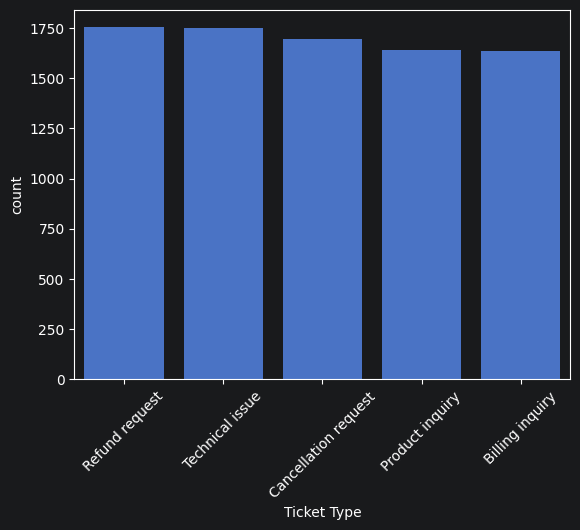

In [8]:
ticket_type_order = df["Ticket Type"].value_counts().index
sns.countplot(data=df, x="Ticket Type", order=ticket_type_order)
plt.xticks(rotation=45)
plt.show()

In [9]:
ticket_type_counts = df["Ticket Type"].value_counts().reset_index()
ticket_type_counts.columns = ["Ticket Type", "ticket_type_counts"]
# ticket_type_counts.isna().sum()
fig = px.bar(ticket_type_counts, x="Ticket Type", y="ticket_type_counts")
fig.show()

***MOST CLOSED TICKET TYPES***

In [10]:
print(df["Ticket Status"].value_counts())
df[df["Ticket Status"] == "Closed"]["Ticket Type"].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


Ticket Type
Refund request          596
Technical issue         580
Billing inquiry         544
Product inquiry         533
Cancellation request    516
Name: count, dtype: int64

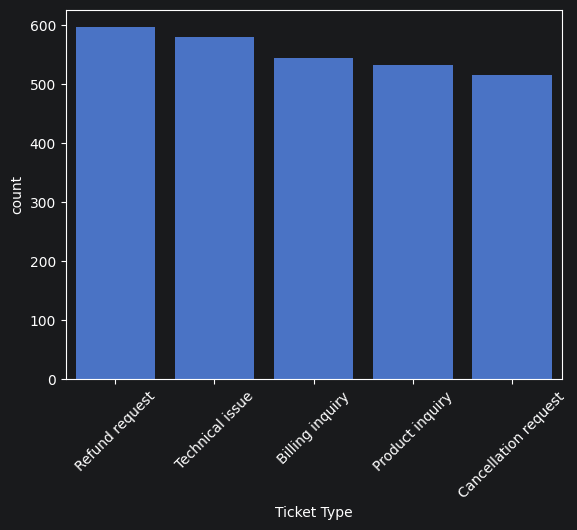

In [11]:
most_closed_tickets = df[df["Ticket Status"] == "Closed"]["Ticket Type"].value_counts().index
sns.countplot(data=df, x=df[df["Ticket Status"] == "Closed"]["Ticket Type"], order=most_closed_tickets)
plt.xticks(rotation=45)
plt.show()

In [12]:
most_closed_tickets_count = df[df["Ticket Status"] == "Closed"]["Ticket Type"].value_counts().reset_index()
most_closed_tickets_count.columns = ["Ticket Type", "most_closed_tickets_count"]
fig = px.bar(most_closed_tickets_count, x="Ticket Type", y="most_closed_tickets_count")
fig.show()

***MOST OPEN TICKET TYPES***

In [13]:
df[df["Ticket Status"] == "Open"]["Ticket Type"].value_counts()
most_open_ticket_types = df[df["Ticket Status"] == "Open"]["Ticket Type"].value_counts()

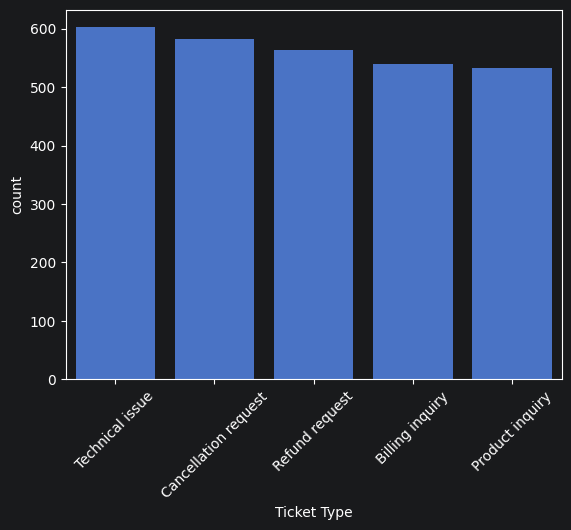

In [14]:
most_open_ticket_types = df[df["Ticket Status"] == "Open"]["Ticket Type"].value_counts().index
sns.countplot(data=df, x=df[df["Ticket Status"] == "Open"]["Ticket Type"], order=most_open_ticket_types)
plt.xticks(rotation=45)
plt.show()

In [15]:
most_open_tickets_count = df[df["Ticket Status"] == "Open"]["Ticket Type"].value_counts().reset_index()
most_open_tickets_count.columns = ["Ticket Type", "most_open_tickets_count"]
fig = px.bar(most_open_tickets_count, x="Ticket Type", y="most_open_tickets_count")
fig.show()

***PENDING RESPONSE TICKETS***

In [16]:
df[df["Ticket Status"] == "Pending Customer Response"]["Ticket Type"].value_counts()

Ticket Type
Cancellation request    597
Refund request          592
Product inquiry         576
Technical issue         565
Billing inquiry         551
Name: count, dtype: int64

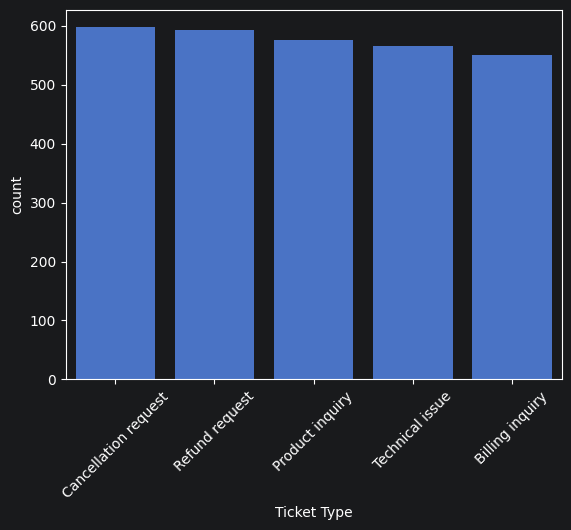

In [17]:
pending_tickets = df[df["Ticket Status"] == "Pending Customer Response"]["Ticket Type"].value_counts().index
sns.countplot(data=df, x=df[df["Ticket Status"] == "Pending Customer Response"]["Ticket Type"], order=pending_tickets)
plt.xticks(rotation=45)
plt.show()

***DISTRIBUTION BY TICKET PRIORITY***

In [18]:
df["Ticket Priority"].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

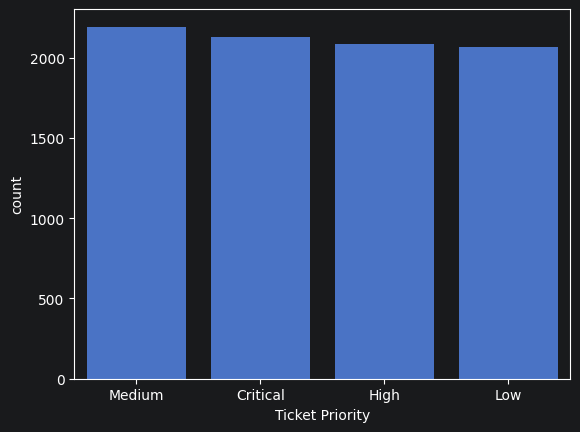

In [19]:
ticket_priority = df["Ticket Priority"].value_counts().index
sns.countplot(data=df, x="Ticket Priority", order=ticket_priority)
plt.show()

In [20]:
# Ticket types and the priority given
priority_type = df.groupby(["Ticket Priority", "Ticket Type"]).size().reset_index(name="count")
priority_type.sort_values(by=["Ticket Priority", "count"], ascending=[True, False], inplace=True)
priority_type

,Ticket Priority,Ticket Type,count
3,Critical,Refund request,444
4,Critical,Technical issue,439
1,Critical,Cancellation request,423
0,Critical,Billing inquiry,420
2,Critical,Product inquiry,403
9,High,Technical issue,458
8,High,Refund request,448
7,High,Product inquiry,399
6,High,Cancellation request,398
5,High,Billing inquiry,382


In [21]:
priority_type_plot = priority_type.reset_index()

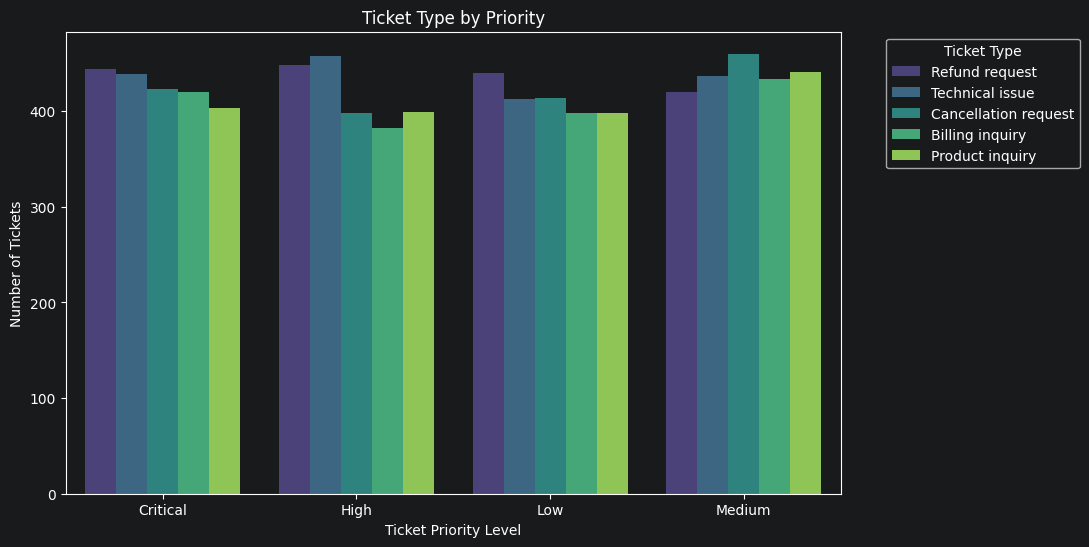

In [22]:
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    data=priority_type_plot,
    x="Ticket Priority",
    y="count",
    hue="Ticket Type",
    palette="viridis"
)
plt.title('Ticket Type by Priority')
plt.ylabel("Number of Tickets")
plt.xlabel("Ticket Priority Level")
plt.legend(title="Ticket Type", bbox_to_anchor=(1.05,1),  loc="upper left")
plt.show()

***Distribution by Support Channel***
> Visualize most common support channels
> Ticket priority by Channel ~ Does the Ticket Priority influence the channel used

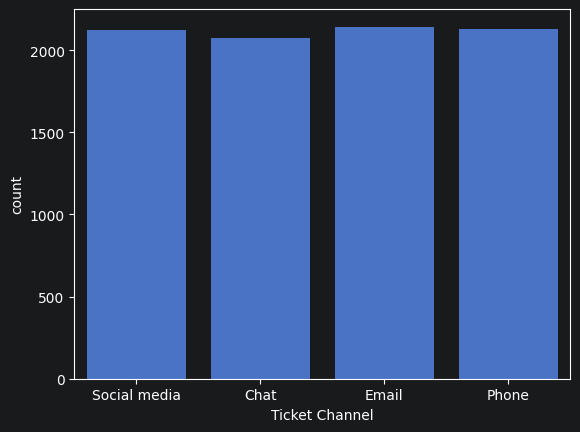

In [23]:
sns.countplot(data=df, x="Ticket Channel")
plt.show()

In [24]:
support_channel = df.groupby(["Ticket Channel", "Ticket Priority"]).size().reset_index(name="count")
support_channel.sort_values(by=["Ticket Channel", "count"], inplace=True)

support_channel

,Ticket Channel,Ticket Priority,count
2,Chat,Low,501
0,Chat,Critical,504
1,Chat,High,517
3,Chat,Medium,551
5,Email,High,504
6,Email,Low,525
7,Email,Medium,543
4,Email,Critical,571
10,Phone,Low,499
9,Phone,High,512


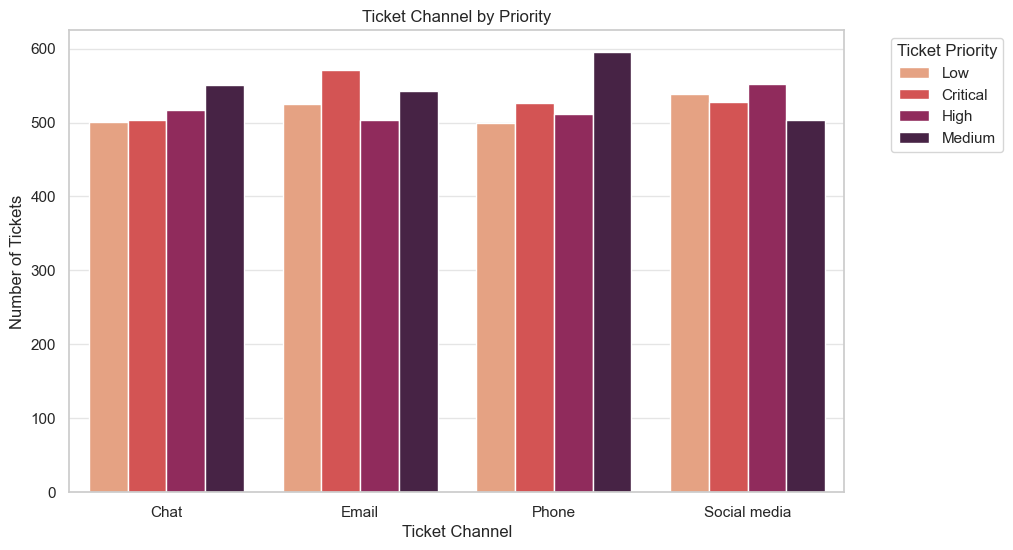

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    data=support_channel,
    x="Ticket Channel",
    y="count",
    hue="Ticket Priority",
    palette="rocket_r"
)
plt.title('Ticket Channel by Priority')
plt.ylabel("Number of Tickets")
plt.xlabel("Ticket Channel")
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05,1),  loc="upper left")
plt.show()

> Ticket Type submission by channel

In [26]:
type_channel = df.groupby(["Ticket Channel", "Ticket Type"]).size().reset_index(name="count")
type_channel.sort_values(by=["Ticket Channel", "count"], inplace=True)

type_channel

,Ticket Channel,Ticket Type,count
2,Chat,Product inquiry,388
0,Chat,Billing inquiry,398
1,Chat,Cancellation request,408
3,Chat,Refund request,426
4,Chat,Technical issue,453
5,Email,Billing inquiry,405
9,Email,Technical issue,408
7,Email,Product inquiry,427
6,Email,Cancellation request,448
8,Email,Refund request,455


> Relationship Between Ticket Type, Ticket Priority and Ticket Channel

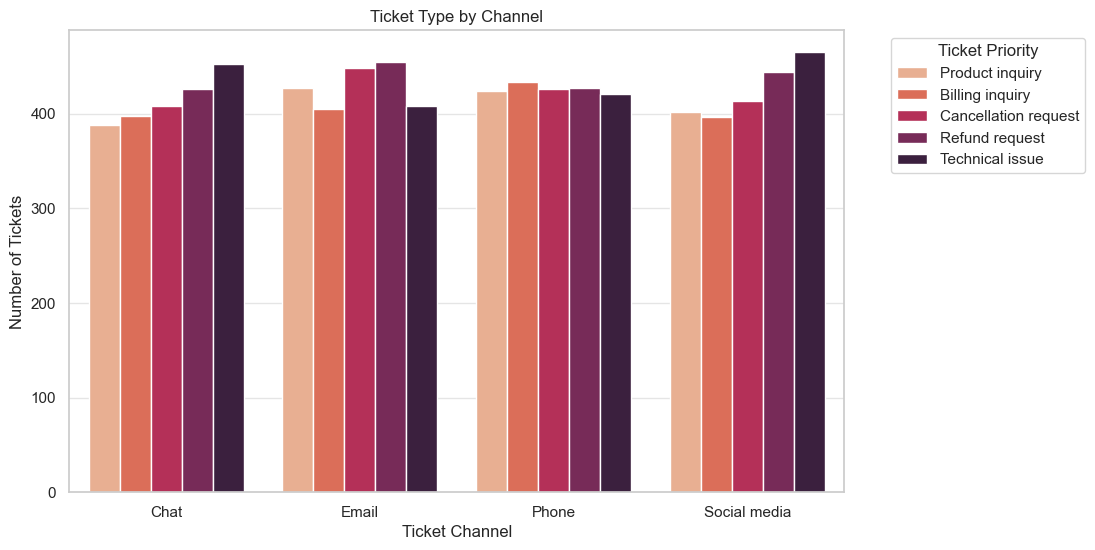

In [27]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    data=type_channel,
    x="Ticket Channel",
    y="count",
    hue="Ticket Type",
    palette="rocket_r"
)
plt.title('Ticket Type by Channel')
plt.ylabel("Number of Tickets")
plt.xlabel("Ticket Channel")
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05,1),  loc="upper left")
plt.show()

In [28]:
channel_type_priority = df[["Ticket Channel","Ticket Priority" ,"Ticket Type"]].value_counts().reset_index(name="ticket_count")
print(channel_type_priority.shape)
channel_type_priority

(80, 4)


,Ticket Channel,Ticket Priority,Ticket Type,ticket_count
0,Phone,Medium,Product inquiry,136
1,Chat,Critical,Technical issue,129
2,Phone,Medium,Cancellation request,128
3,Phone,Medium,Billing inquiry,128
4,Email,Critical,Cancellation request,128
...,...,...,...,...
75,Phone,Low,Product inquiry,89
76,Chat,Critical,Cancellation request,89
77,Chat,High,Billing inquiry,88
78,Email,High,Billing inquiry,86


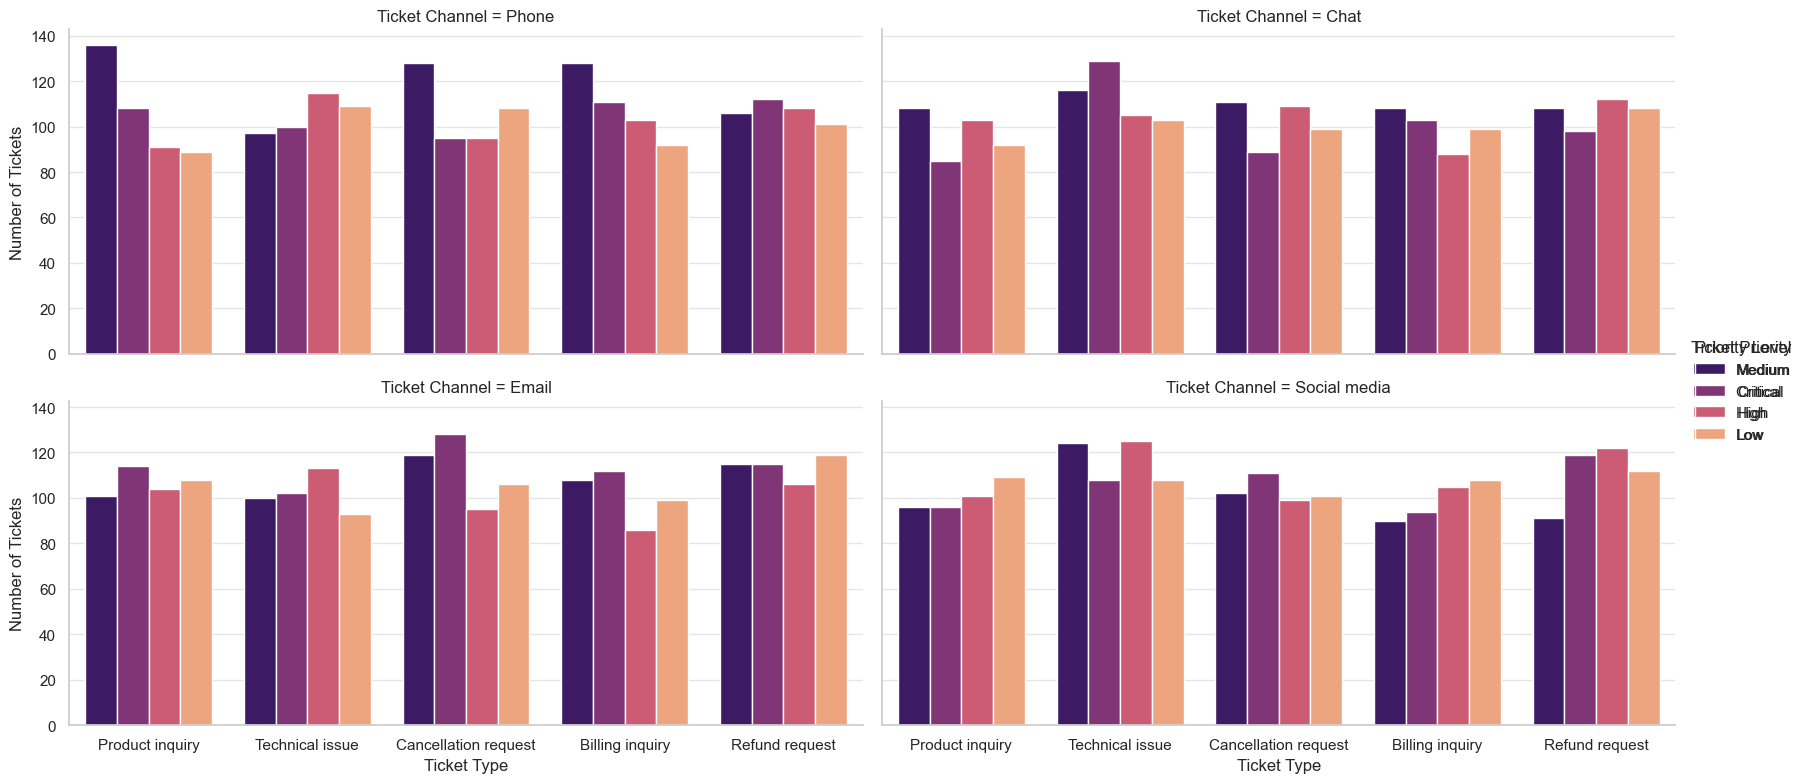

In [29]:
plot = sns.catplot(
    data=channel_type_priority,
    kind="bar",
    x="Ticket Type",
    y="ticket_count",
    hue="Ticket Priority",
    col="Ticket Channel",
    col_wrap=2,
    palette="magma",
    height=4,
    aspect=2
)
plot.set_axis_labels("Ticket Type", "Number of Tickets")
plot.add_legend(title="Priority Level")
plt.show()

***CUSTOMER DEMOGRAPHICS VISUALIZATION***

In [30]:
customer_demographics = df[["Customer Age", "Customer Email", "Customer Gender"]]
customer_demographics

,Customer Age,Customer Email,Customer Gender
0,32,carrollallison@example.com,Other
1,42,clarkeashley@example.com,Female
2,48,gonzalestracy@example.com,Other
3,27,bradleyolson@example.org,Female
4,67,bradleymark@example.com,Female
...,...,...,...
8464,22,adam28@example.net,Female
8465,27,russell68@example.com,Female
8466,57,ashley83@example.org,Female
8467,54,fpowell@example.org,Male


In [31]:
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


***MOST COMMON ISSUES***

In [33]:
df["Ticket Subject"].unique()

<StringArray>
[           'Product setup', 'Peripheral compatibility',
          'Network problem',           'Account access',
                'Data loss',            'Payment issue',
           'Refund request',             'Battery life',
     'Installation support',             'Software bug',
           'Hardware issue',   'Product recommendation',
         'Delivery problem',            'Display issue',
     'Cancellation request',    'Product compatibility']
Length: 16, dtype: str

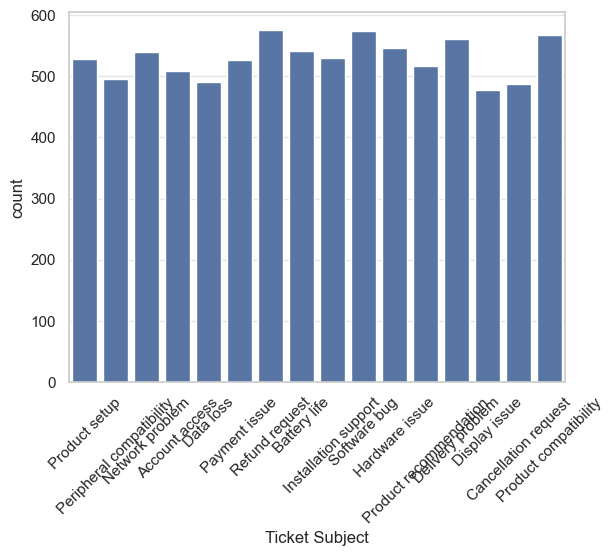

In [34]:
sns.countplot(data=df, x="Ticket Subject")
plt.xticks(rotation=45)
plt.show()

In [35]:
# Ticket Subject with Priority given
subject_priority = df.groupby(["Ticket Subject", "Ticket Priority"]).size().reset_index(name="count")
subject_priority.sort_values(by=["Ticket Subject", "count"], inplace=True)

subject_priority

,Ticket Subject,Ticket Priority,count
0,Account access,Critical,113
1,Account access,High,130
2,Account access,Low,131
3,Account access,Medium,135
4,Battery life,Critical,124
...,...,...,...
56,Refund request,Critical,156
61,Software bug,High,121
60,Software bug,Critical,137
62,Software bug,Low,152


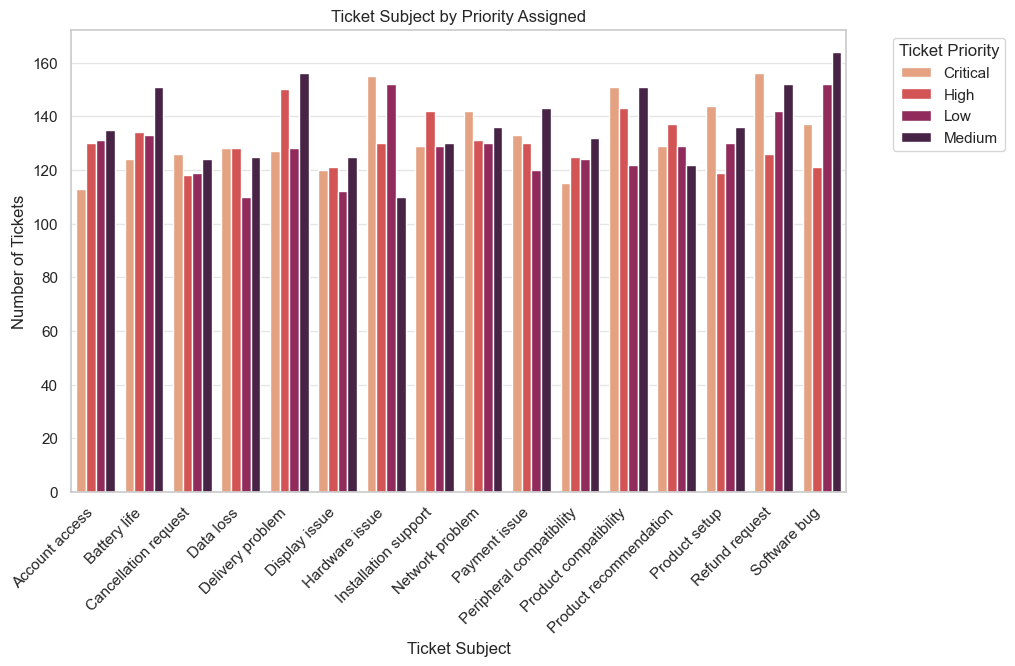

In [36]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

sns.barplot(
    data=subject_priority,
    x="Ticket Subject",
    y="count",
    hue="Ticket Priority",
    palette="rocket_r"

)
plt.xticks(rotation=45, ha='right')
plt.title('Ticket Subject by Priority Assigned')
plt.ylabel("Number of Tickets")
plt.xlabel("Ticket Subject")
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05,1),  loc="upper left")
plt.show()

From the chart; Refund Request, Hardware Issue and Product compatibility are mostly assigned Critical Priority